# Clean Multi-Task BERTweet Humor Training Notebook

This notebook retrains the multi-task BERTweet model from scratch, saves it in a backend-friendly format, reloads it with `strict=True`, tests the reloaded model, compares original vs reloaded predictions, and downloads the final zip.

Tasks predicted:

1. Humor detection: humorous vs not humorous
2. Humor rating: 0–5
3. Offense rating: 0–5
4. Humor controversy: controversial vs not controversial

The important part: **the downloaded model is tested after reload before it is zipped/downloaded**.

In [21]:

# Colab setup
!pip install -q transformers datasets accelerate evaluate emoji scikit-learn matplotlib pandas numpy

## 1. Imports and global settings

In [22]:

import os
import json
import shutil
import random
import inspect
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import Dataset

# Colab can ship a torchvision build without VideoReader.
# The Hugging Face datasets Torch formatter may try to import it while tensorizing rows.
# This model is text-only, so torchvision is irrelevant; disabling this avoids a fake crash.
import datasets.config as datasets_config
datasets_config.TORCHVISION_AVAILABLE = False

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    mean_squared_error,
    mean_absolute_error,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModel,
    PreTrainedModel,
    TrainingArguments,
    Trainer,
)
from transformers.modeling_outputs import SequenceClassifierOutput

import matplotlib.pyplot as plt

SEED = 42
MODEL_NAME = "vinai/bertweet-base"
MAX_LENGTH = 128
EXPORT_DIR = "/content/bertweet_multitask_humor_model"
ZIP_PATH = "/content/bertweet_multitask_humor_model.zip"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Avoid weird meta-device leftovers in notebooks.
torch.set_default_device("cpu")

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.11.0+cu128
CUDA available: True


## 2. Download and load the HaHackathon dataset

This uses the same SemEval 2021 Task 7 / HaHackathon dataset format.

In [23]:

!git clone -q https://github.com/NLP-UMUTeam/SemEval2021-HaHackathon-UMUTeam.git /content/SemEval2021-HaHackathon-UMUTeam || true

train_path = "/content/SemEval2021-HaHackathon-UMUTeam/datasets/hahackathon_train.csv"
df_raw = pd.read_csv(train_path)

print("Raw shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())
df_raw.head()

fatal: destination path '/content/SemEval2021-HaHackathon-UMUTeam' already exists and is not an empty directory.
Raw shape: (8000, 6)
Columns: ['id', 'text', 'is_humor', 'humor_rating', 'humor_controversy', 'offense_rating']


,id,text,is_humor,humor_rating,humor_controversy,offense_rating
0,1,TENNESSEE: We're the best state. Nobody even c...,1,2.42,1.0,0.2
1,2,A man inserted an advertisement in the classif...,1,2.50,1.0,1.1
2,3,How many men does it take to open a can of bee...,1,1.95,0.0,2.4
3,4,Told my mom I hit 1200 Twitter followers. She ...,1,2.11,1.0,0.0
4,5,Roses are dead. Love is fake. Weddings are bas...,1,2.78,0.0,0.1


## 3. Prepare clean multi-task labels

The labels are normalized into a stable schema used by both training and inference.

In [24]:

def find_col(possible_names, columns):
    columns_lower = {c.lower(): c for c in columns}
    for name in possible_names:
        if name.lower() in columns_lower:
            return columns_lower[name.lower()]
    raise ValueError(f"Could not find any of these columns: {possible_names}")

text_col = find_col(["text", "sentence", "tweet"], df_raw.columns)
humor_col = find_col(["is_humor", "humor", "label"], df_raw.columns)
humor_rating_col = find_col(["humor_rating", "humor_score", "funniness_average"], df_raw.columns)
offense_rating_col = find_col(["offense_rating", "offense_score"], df_raw.columns)
controversy_col = find_col(["humor_controversy", "controversy", "is_controversial"], df_raw.columns)

print("text:", text_col)
print("humor label:", humor_col)
print("humor rating:", humor_rating_col)
print("offense rating:", offense_rating_col)
print("controversy:", controversy_col)

df = df_raw[[text_col, humor_col, humor_rating_col, offense_rating_col, controversy_col]].copy()
df.columns = ["text", "labels_humor", "labels_humor_rating", "labels_offense_rating", "labels_controversy"]

# Text
df["text"] = df["text"].astype(str).fillna("")

# Binary humor label: 0/1
df["labels_humor"] = pd.to_numeric(df["labels_humor"], errors="coerce").fillna(0).astype(int)
df["labels_humor"] = df["labels_humor"].clip(0, 1)

# Regression labels: keep NaN if missing; the model masks NaNs during loss.
df["labels_humor_rating"] = pd.to_numeric(df["labels_humor_rating"], errors="coerce").astype(float)
df["labels_offense_rating"] = pd.to_numeric(df["labels_offense_rating"], errors="coerce").astype(float)

# Controversy is normally only meaningful for humorous examples.
# Missing controversy gets -100 so the loss ignores it.
df["labels_controversy"] = pd.to_numeric(df["labels_controversy"], errors="coerce")
df["labels_controversy"] = df["labels_controversy"].fillna(-100).astype(int)
df.loc[df["labels_controversy"].isin([0, 1]) == False, "labels_controversy"] = -100

print(df.dtypes)
print(df.head())
print("Humor label distribution:")
print(df["labels_humor"].value_counts())
print("Controversy label distribution including ignored -100:")
print(df["labels_controversy"].value_counts())

text: text
humor label: is_humor
humor rating: humor_rating
offense rating: offense_rating
controversy: humor_controversy
text                      object
labels_humor               int64
labels_humor_rating      float64
labels_offense_rating    float64
labels_controversy         int64
dtype: object
                                                text  labels_humor  \
0  TENNESSEE: We're the best state. Nobody even c...             1   
1  A man inserted an advertisement in the classif...             1   
2  How many men does it take to open a can of bee...             1   
3  Told my mom I hit 1200 Twitter followers. She ...             1   
4  Roses are dead. Love is fake. Weddings are bas...             1   

   labels_humor_rating  labels_offense_rating  labels_controversy  
0                 2.42                    0.2                   1  
1                 2.50                    1.1                   1  
2                 1.95                    2.4                   0  
3     

## 4. Train/validation split

In [25]:

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["labels_humor"],
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Train labels:")
print(train_df["labels_humor"].value_counts())
print("Validation labels:")
print(val_df["labels_humor"].value_counts())

Train: (6400, 5)
Validation: (1600, 5)
Train labels:
labels_humor
1    3946
0    2454
Name: count, dtype: int64
Validation labels:
labels_humor
1    986
0    614
Name: count, dtype: int64


## 5. Tokenize with BERTweet

Important: use the same tokenizer settings here and in the app: `use_fast=False`, `normalization=True`, `max_length=128`.

In [26]:

datasets_config.TORCHVISION_AVAILABLE = False  # repeated intentionally before set_format

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=False,
    normalization=True,
)

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

columns = [
    "input_ids",
    "attention_mask",
    "labels_humor",
    "labels_humor_rating",
    "labels_offense_rating",
    "labels_controversy",
]

train_dataset.set_format(type="torch", columns=columns)
val_dataset.set_format(type="torch", columns=columns)

print("Torch columns:", columns)
print("Dataset is ready. First text preview:", train_df.iloc[0]["text"][:120])

Map:   0%|          | 0/6400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Torch columns: ['input_ids', 'attention_mask', 'labels_humor', 'labels_humor_rating', 'labels_offense_rating', 'labels_controversy']
Dataset is ready. First text preview: I left my wife because she was obsessed with counting. I wonder what she's up to now.


## 6. Define the custom multi-task model

This class must be the same in training and backend inference.

In [27]:

# Transformers newer versions may inspect the source file of custom PreTrainedModel subclasses.
# In notebooks, classes live in __main__, which has no __file__, causing:
# AttributeError: module '__main__' has no attribute '__file__'
#
# Fix: define the custom model in a real .py module, then import it.

model_py = r"""
import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import AutoConfig, AutoModel, PreTrainedModel
from transformers.modeling_outputs import SequenceClassifierOutput


class BertweetMultiTaskModel(PreTrainedModel):
    config_class = AutoConfig

    def __init__(self, config):
        super().__init__(config)

        base_model_name = getattr(config, "base_model_name", "vinai/bertweet-base")
        self.bertweet = AutoModel.from_pretrained(base_model_name, config=config)

        hidden_size = config.hidden_size
        dropout_prob = getattr(config, "hidden_dropout_prob", 0.1)

        self.dropout = nn.Dropout(dropout_prob)
        self.humor_classifier = nn.Linear(hidden_size, 2)
        self.controversy_classifier = nn.Linear(hidden_size, 2)
        self.humor_regressor = nn.Linear(hidden_size, 1)
        self.offense_regressor = nn.Linear(hidden_size, 1)

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        labels_humor=None,
        labels_humor_rating=None,
        labels_offense_rating=None,
        labels_controversy=None,
        **kwargs,
    ):
        outputs = self.bertweet(
            input_ids=input_ids,
            attention_mask=attention_mask,
            **kwargs,
        )

        pooled = outputs.last_hidden_state[:, 0, :]
        pooled = self.dropout(pooled)

        logits_humor = self.humor_classifier(pooled)
        logits_controversy = self.controversy_classifier(pooled)
        pred_humor_rating = self.humor_regressor(pooled).squeeze(-1)
        pred_offense_rating = self.offense_regressor(pooled).squeeze(-1)

        losses = []

        if labels_humor is not None:
            losses.append(F.cross_entropy(logits_humor, labels_humor.long()))

        if labels_humor_rating is not None:
            labels_humor_rating = labels_humor_rating.float()
            mask = ~torch.isnan(labels_humor_rating)
            if mask.any():
                losses.append(F.mse_loss(pred_humor_rating[mask], labels_humor_rating[mask]))

        if labels_offense_rating is not None:
            labels_offense_rating = labels_offense_rating.float()
            mask = ~torch.isnan(labels_offense_rating)
            if mask.any():
                losses.append(F.mse_loss(pred_offense_rating[mask], labels_offense_rating[mask]))

        if labels_controversy is not None:
            labels_controversy = labels_controversy.long()
            mask = labels_controversy != -100
            if mask.any():
                losses.append(F.cross_entropy(logits_controversy[mask], labels_controversy[mask]))

        loss = sum(losses) if losses else None

        return SequenceClassifierOutput(
            loss=loss,
            logits=(
                logits_humor,
                pred_humor_rating,
                pred_offense_rating,
                logits_controversy,
            ),
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )
"""

with open("/content/bertweet_multitask_model.py", "w", encoding="utf-8") as f:
    f.write(model_py)

import sys, importlib
sys.path.insert(0, "/content")

import bertweet_multitask_model
importlib.reload(bertweet_multitask_model)

from bertweet_multitask_model import BertweetMultiTaskModel

config = AutoConfig.from_pretrained(MODEL_NAME)
config.base_model_name = MODEL_NAME

# Do NOT set config.problem_type = "multi_task_humor"
# Do NOT set config.max_length = MAX_LENGTH

config.id2label = {0: "Not humorous", 1: "Humorous"}
config.label2id = {"Not humorous": 0, "Humorous": 1}

model = BertweetMultiTaskModel(config)
print("Model created")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model created


## 7. Metrics

In [28]:

def safe_rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    logits_humor, pred_humor_rating, pred_offense_rating, logits_controversy = predictions
    labels_humor, labels_humor_rating, labels_offense_rating, labels_controversy = labels

    humor_pred = np.argmax(logits_humor, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_humor,
        humor_pred,
        average="binary",
        zero_division=0,
    )

    metrics = {
        "humor_accuracy": accuracy_score(labels_humor, humor_pred),
        "humor_precision": precision,
        "humor_recall": recall,
        "humor_f1": f1,
    }

    humor_mask = ~np.isnan(labels_humor_rating.astype(float))
    if humor_mask.any():
        metrics["humor_rating_rmse"] = safe_rmse(labels_humor_rating[humor_mask], pred_humor_rating[humor_mask])
        metrics["humor_rating_mae"] = float(mean_absolute_error(labels_humor_rating[humor_mask], pred_humor_rating[humor_mask]))

    offense_mask = ~np.isnan(labels_offense_rating.astype(float))
    if offense_mask.any():
        metrics["offense_rating_rmse"] = safe_rmse(labels_offense_rating[offense_mask], pred_offense_rating[offense_mask])
        metrics["offense_rating_mae"] = float(mean_absolute_error(labels_offense_rating[offense_mask], pred_offense_rating[offense_mask]))

    controversy_mask = labels_controversy != -100
    if controversy_mask.any():
        controversy_pred = np.argmax(logits_controversy, axis=-1)
        c_precision, c_recall, c_f1, _ = precision_recall_fscore_support(
            labels_controversy[controversy_mask],
            controversy_pred[controversy_mask],
            average="binary",
            zero_division=0,
        )
        metrics["controversy_accuracy"] = accuracy_score(labels_controversy[controversy_mask], controversy_pred[controversy_mask])
        metrics["controversy_f1"] = c_f1

    return metrics

## 8. Train

For a solid run, keep `num_train_epochs=3`. If you need a faster smoke test, temporarily set it to `1`.

In [29]:

# Make TrainingArguments compatible with slightly different transformers versions.
args_kwargs = dict(
    output_dir="/content/bertweet-multitask-training-output",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="humor_f1",
    greater_is_better=True,
    logging_dir="/content/logs",
    logging_steps=50,
    report_to="none",
    label_names=[
        "labels_humor",
        "labels_humor_rating",
        "labels_offense_rating",
        "labels_controversy",
    ],
    remove_unused_columns=False,
)

sig = inspect.signature(TrainingArguments.__init__)
if "eval_strategy" in sig.parameters:
    args_kwargs["eval_strategy"] = "epoch"
else:
    args_kwargs["evaluation_strategy"] = "epoch"

training_args = TrainingArguments(**args_kwargs)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()
print(train_result)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Humor Accuracy,Humor Precision,Humor Recall,Humor F1,Humor Rating Rmse,Humor Rating Mae,Offense Rating Rmse,Offense Rating Mae,Controversy Accuracy,Controversy F1
1,1.575356,1.457608,0.948750,0.963115,0.953347,0.958206,0.525019,0.412543,0.583168,0.348357,0.545639,0.487414
2,1.327639,1.405558,0.951875,0.979937,0.941176,0.960166,0.510031,0.401375,0.562478,0.320678,0.562880,0.581147
3,1.137907,1.393562,0.957500,0.971253,0.959432,0.965306,0.512222,0.402550,0.557140,0.324614,0.550710,0.604817


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1200, training_loss=1.4615385754903158, metrics={'train_runtime': 685.8365, 'train_samples_per_second': 27.995, 'train_steps_per_second': 1.75, 'total_flos': 1262978423193600.0, 'train_loss': 1.4615385754903158, 'epoch': 3.0})


## 9. Evaluate trained model

In [30]:

eval_results = trainer.evaluate()
print(json.dumps(eval_results, indent=2))

Training Loss,Validation Loss,Epoch,Humor Accuracy,Humor Precision,Humor Recall,Humor F1,Humor Rating Rmse,Humor Rating Mae,Offense Rating Rmse,Offense Rating Mae,Controversy Accuracy,Controversy F1
1.137907,1.393562,3,0.957500,0.971253,0.959432,0.965306,0.512222,0.402550,0.557140,0.324614,0.550710,0.604817


{
  "eval_loss": 1.3935619592666626,
  "eval_humor_accuracy": 0.9575,
  "eval_humor_precision": 0.971252566735113,
  "eval_humor_recall": 0.9594320486815415,
  "eval_humor_f1": 0.9653061224489796,
  "eval_humor_rating_rmse": 0.512221606168126,
  "eval_humor_rating_mae": 0.4025496244430542,
  "eval_offense_rating_rmse": 0.557140059363673,
  "eval_offense_rating_mae": 0.3246135711669922,
  "eval_controversy_accuracy": 0.550709939148073,
  "eval_controversy_f1": 0.6048171275646744
}


              precision    recall  f1-score   support

Not humorous       0.94      0.95      0.95       614
    Humorous       0.97      0.96      0.97       986

    accuracy                           0.96      1600
   macro avg       0.95      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600



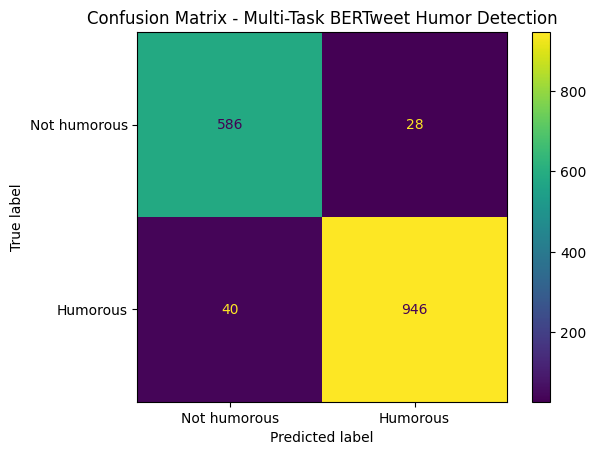

In [31]:

pred_output = trainer.predict(val_dataset)
logits_humor, pred_humor_rating, pred_offense_rating, logits_controversy = pred_output.predictions
labels_humor, labels_humor_rating, labels_offense_rating, labels_controversy = pred_output.label_ids

y_pred = np.argmax(logits_humor, axis=-1)

print(classification_report(
    labels_humor,
    y_pred,
    target_names=["Not humorous", "Humorous"],
    zero_division=0,
))

cm = confusion_matrix(labels_humor, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not humorous", "Humorous"])
disp.plot()
plt.title("Confusion Matrix - Multi-Task BERTweet Humor Detection")
plt.show()

## 10. Prediction helper

In [32]:

def predict_with_model(model_obj, tokenizer_obj, text, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model_obj.to(device)
    model_obj.eval()

    inputs = tokenizer_obj(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model_obj(**inputs)
        logits_humor, pred_humor_rating, pred_offense_rating, logits_controversy = outputs.logits
        humor_probs = F.softmax(logits_humor, dim=-1)[0]
        controversy_probs = F.softmax(logits_controversy, dim=-1)[0]

    humor_label_id = int(torch.argmax(humor_probs).item())
    controversy_id = int(torch.argmax(controversy_probs).item())

    humor_score = float(pred_humor_rating[0].item())
    offense_score = float(pred_offense_rating[0].item())

    humor_score = max(0.0, min(5.0, humor_score))
    offense_score = max(0.0, min(5.0, offense_score))

    return {
        "label": "Humorous" if humor_label_id == 1 else "Not humorous",
        "confidence": round(float(humor_probs[humor_label_id].item()), 6),
        "not_humorous_probability": round(float(humor_probs[0].item()), 6),
        "humorous_probability": round(float(humor_probs[1].item()), 6),
        "humor_rating_0_to_5": round(humor_score, 2),
        "offense_rating_0_to_5": round(offense_score, 2),
        "controversial": bool(controversy_id),
        "controversy_probability": round(float(controversy_probs[1].item()), 6),
    }

examples = [
    "I used to play piano by ear, but now I use my hands.",
    "The database backup completed successfully.",
    "The meeting will start tomorrow at 10 AM.",
    "My cat looked at the expensive food I bought and decided starvation was more dignified.",
    "I told my computer I needed a break, and now it won't stop sending me vacation ads.",
]

print("Predictions from trained in-memory model:")
for text in examples:
    print(text)
    print(predict_with_model(trainer.model, tokenizer, text))
    print("-" * 70)

Predictions from trained in-memory model:
I used to play piano by ear, but now I use my hands.
{'label': 'Humorous', 'confidence': 0.983485, 'not_humorous_probability': 0.016515, 'humorous_probability': 0.983485, 'humor_rating_0_to_5': 2.91, 'offense_rating_0_to_5': 0.0, 'controversial': True, 'controversy_probability': 0.527725}
----------------------------------------------------------------------
The database backup completed successfully.
{'label': 'Not humorous', 'confidence': 0.967502, 'not_humorous_probability': 0.967502, 'humorous_probability': 0.032498, 'humor_rating_0_to_5': 1.83, 'offense_rating_0_to_5': 0.0, 'controversial': False, 'controversy_probability': 0.481525}
----------------------------------------------------------------------
The meeting will start tomorrow at 10 AM.
{'label': 'Not humorous', 'confidence': 0.980131, 'not_humorous_probability': 0.980131, 'humorous_probability': 0.019869, 'humor_rating_0_to_5': 1.47, 'offense_rating_0_to_5': 0.0, 'controversial': 

## 11. Save backend-friendly export

This export uses a normal PyTorch state dict and a tokenizer/config folder. The backend should load `multitask_model_state.pt` with `strict=True`.

In [36]:
export_path = Path(EXPORT_DIR)
if export_path.exists():
    shutil.rmtree(export_path)
export_path.mkdir(parents=True, exist_ok=True)

# Put trained model on CPU and eval before freezing weights.
trainer.model.cpu()
trainer.model.eval()

# Save tokenizer and config.
tokenizer.save_pretrained(EXPORT_DIR)
trainer.model.config.save_pretrained(EXPORT_DIR)

# IMPORTANT: clone the exact trained tensors.
state_dict_to_save = {
    k: v.detach().cpu().clone()
    for k, v in trainer.model.state_dict().items()
}

state_path = export_path / "multitask_model_state.pt"
torch.save(state_dict_to_save, state_path)

# Save exact architecture file.
shutil.copy("/content/bertweet_multitask_model.py", export_path / "bertweet_multitask_model.py")

model_info = {
    "base_model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "architecture": "BertweetMultiTaskModel",
    "state_dict_file": "multitask_model_state.pt",
    "tasks": ["humor_detection", "humor_rating", "offense_rating", "humor_controversy"],
    "label_mapping": {"0": "Not humorous", "1": "Humorous"},
    "important": "Load multitask_model_state.pt with strict=True. Do not use strict=False.",
}

with open(export_path / "model_info.json", "w", encoding="utf-8") as f:
    json.dump(model_info, f, indent=2)

print("Saved export files:")
for p in sorted(export_path.iterdir()):
    print(" -", p.name)

print("Saved state dict tensors:", len(state_dict_to_save))
print("Sample saved key:", next(iter(state_dict_to_save)))


Saved export files:
 - added_tokens.json
 - bertweet_multitask_model.py
 - bpe.codes
 - config.json
 - model_info.json
 - multitask_model_state.pt
 - tokenizer_config.json
 - vocab.txt
Saved state dict tensors: 207
Sample saved key: bertweet.embeddings.word_embeddings.weight


## 12. Reload from disk with `strict=True`

This is the most important test. If this cell fails, do **not** use the export.

In [40]:
torch.set_default_device("cpu")

# Reload tokenizer.
reloaded_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=False,
    normalization=True,
)

# Reload config.
reloaded_config = AutoConfig.from_pretrained(EXPORT_DIR)
reloaded_config.base_model_name = MODEL_NAME

# Reload architecture.
import sys, importlib
sys.path.insert(0, "/content")

import bertweet_multitask_model
importlib.reload(bertweet_multitask_model)

from bertweet_multitask_model import BertweetMultiTaskModel

reloaded_model = BertweetMultiTaskModel(reloaded_config)
reloaded_state_dict = torch.load(state_path, map_location="cpu")

# Strict load.
load_result = reloaded_model.load_state_dict(reloaded_state_dict, strict=True)
reloaded_model.cpu()
reloaded_model.eval()

print("Reload successful with strict=True ✅")
print(load_result)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Reload successful with strict=True ✅
<All keys matched successfully>


In [41]:
# Tensor-level equality check between original trained model and reloaded model.
trainer.model.cpu()
trainer.model.eval()
reloaded_model.cpu()
reloaded_model.eval()

original_sd = trainer.model.state_dict()
reloaded_sd = reloaded_model.state_dict()

tensor_max_diff = 0.0
worst_key = None

for key in original_sd:
    diff = torch.max(torch.abs(original_sd[key].detach().cpu() - reloaded_sd[key].detach().cpu())).item()
    if diff > tensor_max_diff:
        tensor_max_diff = diff
        worst_key = key

print("Tensor max diff:", tensor_max_diff)
print("Worst key:", worst_key)

assert tensor_max_diff < 1e-7, f"Weights are not identical! Worst key: {worst_key}, diff: {tensor_max_diff}"
print("Original and reloaded weights are identical ✅")

Tensor max diff: 0.0
Worst key: None
Original and reloaded weights are identical ✅


## 13. Compare original vs reloaded predictions

The probabilities should be identical or extremely close. Tiny floating-point differences are fine.

In [42]:
def raw_humor_probs(model_obj, tokenizer_obj, text):
    model_obj.cpu()
    model_obj.eval()

    inputs = tokenizer_obj(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

    with torch.no_grad():
        outputs = model_obj(**inputs)
        logits_humor = outputs.logits[0]
        probs = F.softmax(logits_humor, dim=-1)[0].detach().cpu().numpy()

    return probs, inputs["input_ids"][0][:20].tolist()


max_diff = 0.0

for text in examples:
    p1, ids1 = raw_humor_probs(trainer.model, tokenizer, text)
    p2, ids2 = raw_humor_probs(reloaded_model, reloaded_tokenizer, text)

    print(text)
    print("same token ids:", ids1 == ids2)
    print("original ids:", ids1)
    print("reloaded ids:", ids2)

    diff = float(np.max(np.abs(p1 - p2)))
    max_diff = max(max_diff, diff)

    print("original:", p1)
    print("reloaded:", p2)
    print("max diff:", diff)
    print("-" * 70)

print("Overall max diff:", max_diff)
assert max_diff < 1e-5, f"Reloaded predictions differ too much: {max_diff}"
print("Original and reloaded predictions match ✅")

I used to play piano by ear, but now I use my hands.
same token ids: True
original ids: [0, 8, 372, 9, 275, 8223, 61, 3311, 7, 42, 77, 8, 310, 23, 1037, 4, 2, 1, 1, 1]
reloaded ids: [0, 8, 372, 9, 275, 8223, 61, 3311, 7, 42, 77, 8, 310, 23, 1037, 4, 2, 1, 1, 1]
original: [0.0165147 0.9834853]
reloaded: [0.0165147 0.9834853]
max diff: 0.0
----------------------------------------------------------------------
The database backup completed successfully.
same token ids: True
original ids: [0, 47, 17010, 3862, 3185, 9743, 4, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
reloaded ids: [0, 47, 17010, 3862, 3185, 9743, 4, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
original: [0.96750236 0.03249771]
reloaded: [0.96750236 0.03249771]
max diff: 0.0
----------------------------------------------------------------------
The meeting will start tomorrow at 10 AM.
same token ids: True
original ids: [0, 47, 1560, 70, 297, 266, 35, 251, 710, 4, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1]
reloaded ids: [0, 47, 1560, 70, 297, 266,

## 14. Final sanity predictions from the reloaded model

These are the predictions you should trust, because they come from the exported/reloaded model.

In [43]:

print("Predictions from exported + reloaded model:")
for text in examples:
    print(text)
    print(predict_with_model(reloaded_model, reloaded_tokenizer, text))
    print("-" * 70)

Predictions from exported + reloaded model:
I used to play piano by ear, but now I use my hands.
{'label': 'Humorous', 'confidence': 0.983485, 'not_humorous_probability': 0.016515, 'humorous_probability': 0.983485, 'humor_rating_0_to_5': 2.91, 'offense_rating_0_to_5': 0.0, 'controversial': True, 'controversy_probability': 0.527725}
----------------------------------------------------------------------
The database backup completed successfully.
{'label': 'Not humorous', 'confidence': 0.967502, 'not_humorous_probability': 0.967502, 'humorous_probability': 0.032498, 'humor_rating_0_to_5': 1.83, 'offense_rating_0_to_5': 0.0, 'controversial': False, 'controversy_probability': 0.481525}
----------------------------------------------------------------------
The meeting will start tomorrow at 10 AM.
{'label': 'Not humorous', 'confidence': 0.980131, 'not_humorous_probability': 0.980131, 'humorous_probability': 0.019869, 'humor_rating_0_to_5': 1.47, 'offense_rating_0_to_5': 0.0, 'controversial'

## 15. Zip and download the tested export

In [44]:

if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

shutil.make_archive(EXPORT_DIR, "zip", EXPORT_DIR)
print("Created:", ZIP_PATH)

try:
    from google.colab import files
    files.download(ZIP_PATH)
except Exception as e:
    print("If you are not in Colab, download manually from:", ZIP_PATH)
    print(e)

Created: /content/bertweet_multitask_humor_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>